# Proyecto aplicado - Fase 2
## Preprocesamiento y análisis exploratorio de datos para reconocimiento facial

Este notebook corresponde a la **Fase 2** del proyecto aplicado. Se reorganiza el flujo del notebook base del proyecto anterior y se conserva únicamente lo que aplica para esta etapa:

1. Carga del dataset desde Google Drive.
2. Exploración inicial del dataset original.
3. Preprocesamiento de imágenes con OpenCV.
4. Limpieza, estandarización y control de errores.
5. Separación del dataset en entrenamiento, validación y prueba.
6. Definición y entrenamiento de dos enfoques de modelamiento solicitados:
   - Modelo 1: Transfer learning con VGG16.
   - Modelo 2: Transfer learning con VGG16 y data augmentation.
7. Resumen de datos, visualizaciones y conclusiones clave.

El énfasis principal de la entrega es cumplir la rúbrica de **preprocesamiento y análisis exploratorio de datos**, dejando además preparado el entrenamiento base solicitado para fases posteriores.

## 0. Relación con la rúbrica de Fase 2

| Criterio de la rúbrica | Cómo se cubre en este notebook |
|---|---|
| Código de preprocesamiento funcional, documentado y con buenas prácticas | Se implementa un pipeline con funciones para lectura, detección facial, recorte, validación, redimensionamiento, guardado y trazabilidad de errores. |
| Limpieza de datos, manejo de valores faltantes y transformación | Se validan imágenes ilegibles, extensiones no soportadas, imágenes sin rostro detectable y recortes inválidos. Las imágenes válidas se transforman a formato JPG y tamaño 224x224. |
| Análisis exploratorio con visualizaciones y estadísticas descriptivas | Se generan tablas y gráficas sobre clases, formatos, tamaños de archivo, dimensiones, imágenes procesadas, fallidas y distribución por partición. |
| Definición clara y completa de los datos | Se incluye descripción del origen, unidad de análisis, variable objetivo, variables construidas, formatos y estructura de carpetas. |
| Reporte completo y bien estructurado con conclusiones clave | Se incluyen secciones de interpretación antes y después del preprocesamiento, además de una tabla final de resumen y conclusiones. |

## 1. Configuración inicial del entorno

En esta sección se instalan dependencias, se descargan los archivos necesarios para la detección facial con OpenCV y se define la configuración general del proyecto.

In [ ]:
# Instalación de dependencias necesarias para Google Colab
!pip install -q gdown pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 22.6 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import zipfile
from pathlib import Path
from glob import glob

import cv2
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from pillow_heif import register_heif_opener

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

register_heif_opener()

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [ ]:
# Rutas principales del proyecto
BASE_DIR = Path("/content")
DATASET_ZIP = BASE_DIR / "dataset.zip"
DATASET_ROOT = BASE_DIR / "dataset"

INPUT_DIR = DATASET_ROOT / "dataset_preparado"
OUTPUT_DIR = BASE_DIR / "dataset_limpio"
ERROR_DIR = BASE_DIR / "imagenes_con_error"
SPLIT_DIR = BASE_DIR / "dataset_split"
REPORTS_DIR = BASE_DIR / "reportes_fase2"

TARGET_SIZE = 224
IMG_SIZE = 224
BATCH_SIZE = 32
SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".heic", ".heif"}

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Rutas configuradas")

Rutas configuradas


In [ ]:
# Limpieza opcional de salidas previas para garantizar reproducibilidad
paths_to_delete = [
    DATASET_ROOT,
    OUTPUT_DIR,
    ERROR_DIR,
    SPLIT_DIR,
    DATASET_ZIP,
]

for path in paths_to_delete:
    if path.exists():
        if path.is_file():
            path.unlink()
        else:
            shutil.rmtree(path)

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print("Entorno limpio y listo para la ejecución")

Entorno limpio y listo para la ejecución


## 2. Carga del dataset desde Google Drive

El notebook original descarga el dataset desde Google Drive mediante `gdown`. Se mantiene esa lógica para que el flujo sea reproducible en Google Colab sin requerir carga manual de archivos.

In [ ]:
# URL del dataset usada en el notebook base
DATASET_URL = "https://drive.google.com/file/d/1RwsG40erRFzCwKcg4YsKl9VwXfavngXj/view?usp=drive_link"

gdown.download(DATASET_URL, str(DATASET_ZIP), fuzzy=True, quiet=False)

if not DATASET_ZIP.exists():
    raise FileNotFoundError("No se descargó dataset.zip. Verifique que el enlace de Google Drive tenga permisos de lectura.")

size_mb = DATASET_ZIP.stat().st_size / (1024 ** 2)
print(f"Tamaño descargado: {size_mb:.2f} MB")

Downloading...
From (original): https://drive.google.com/uc?id=1RwsG40erRFzCwKcg4YsKl9VwXfavngXj
From (redirected): https://drive.google.com/uc?id=1RwsG40erRFzCwKcg4YsKl9VwXfavngXj&confirm=t&uuid=10fb815f-4258-475f-9c07-0dbc56b2a194
To: /content/dataset.zip
100%|██████████| 883M/883M [00:14<00:00, 60.4MB/s]

Tamaño descargado: 842.42 MB


In [ ]:
# Descompresión del dataset
DATASET_ROOT.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    zip_ref.extractall(DATASET_ROOT)

print("Dataset descomprimido en:", DATASET_ROOT)
print("Contenido principal:")
print(os.listdir(DATASET_ROOT))

Dataset descomprimido en: /content/dataset
Contenido principal:
['dataset_preparado']


In [ ]:
# Búsqueda automática de la carpeta dataset_preparado por si el ZIP queda anidado
candidate_dirs = list(DATASET_ROOT.rglob("dataset_preparado"))

if candidate_dirs:
    INPUT_DIR = candidate_dirs[0]
else:
    # Si no existe una carpeta con ese nombre, se intenta usar la primera carpeta que contenga subcarpetas de clases
    possible_dirs = [p for p in DATASET_ROOT.rglob("*") if p.is_dir()]
    possible_with_classes = [p for p in possible_dirs if any(child.is_dir() for child in p.iterdir())]
    if possible_with_classes:
        INPUT_DIR = possible_with_classes[0]

print("Carpeta de entrada seleccionada:", INPUT_DIR)
print("Existe INPUT_DIR:", INPUT_DIR.exists())

if not INPUT_DIR.exists():
    raise FileNotFoundError("No se encontró la carpeta de entrada del dataset. Revise la estructura del ZIP descargado.")

print("Clases encontradas:")
print([p.name for p in INPUT_DIR.iterdir() if p.is_dir()])

Carpeta de entrada seleccionada: /content/dataset/dataset_preparado
Existe INPUT_DIR: True
Clases encontradas:
['nicolas', 'jose', 'juan']


## 3. Definición de los datos utilizados

**Origen de datos.** El dataset corresponde a un conjunto propio de imágenes faciales de los integrantes del proyecto, organizado en carpetas por identidad. Cada subcarpeta representa una clase del problema de clasificación.

**Unidad de análisis.** Cada observación corresponde a una imagen de entrada asociada a una persona.

**Variable objetivo.** La clase o identidad de la persona, inferida a partir del nombre de la carpeta donde se encuentra la imagen.

**Formatos esperados.** El pipeline admite imágenes con extensiones `.jpg`, `.jpeg`, `.png`, `.webp`, `.heic` y `.heif`.

**Transformación esperada.** Las imágenes originales se convierten en imágenes limpias, centradas en el rostro, recortadas en formato cuadrado, redimensionadas a 224x224 píxeles y guardadas como `.jpg`.

### Diccionario de datos construido en el análisis

| Variable | Descripción | Tipo |
|---|---|---|
| `filepath` | Ruta completa del archivo de imagen original. | Texto |
| `filename` | Nombre del archivo. | Texto |
| `class` | Identidad o clase asociada a la imagen. | Categórica |
| `extension` | Formato del archivo original. | Categórica |
| `size_mb` | Tamaño del archivo en megabytes. | Numérica |
| `width` | Ancho original de la imagen en píxeles. | Numérica |
| `height` | Alto original de la imagen en píxeles. | Numérica |
| `readable` | Indica si la imagen pudo abrirse correctamente. | Booleana |
| `split` | Partición asignada: train, validation o test. | Categórica |

## 4. Análisis exploratorio del dataset original

Antes de preprocesar, se revisa la estructura del dataset original: cantidad de imágenes, distribución por clase, formatos presentes, tamaños de archivo y dimensiones originales. Esta revisión permite identificar problemas de calidad y documentar el estado inicial de los datos.

In [ ]:
def get_image_metadata(input_dir: Path, supported_exts=SUPPORTED_EXTS):
    records = []

    for class_dir in sorted([p for p in input_dir.iterdir() if p.is_dir()]):
        class_name = class_dir.name
        for file_path in sorted(class_dir.iterdir()):
            if not file_path.is_file():
                continue

            extension = file_path.suffix.lower()
            is_supported = extension in supported_exts
            width, height, readable = np.nan, np.nan, False

            if is_supported:
                try:
                    with Image.open(file_path) as img:
                        img = ImageOps.exif_transpose(img)
                        width, height = img.size
                        readable = True
                except Exception:
                    readable = False

            records.append({
                "filepath": str(file_path),
                "filename": file_path.name,
                "class": class_name,
                "extension": extension,
                "is_supported_extension": is_supported,
                "size_mb": file_path.stat().st_size / (1024 ** 2),
                "width": width,
                "height": height,
                "readable": readable
            })

    return pd.DataFrame(records)

metadata_df = get_image_metadata(INPUT_DIR)
metadata_df.to_csv(REPORTS_DIR / "metadata_dataset_original.csv", index=False)

metadata_df.head()

,filepath,filename,class,extension,is_supported_extension,size_mb,width,height,readable
0,/content/dataset/dataset_preparado/jose/005A2E...,005A2E03-E81D-4A11-A965-24637613936E_1_105_c.jpeg,jose,.jpeg,True,0.185069,768,1024,True
1,/content/dataset/dataset_preparado/jose/1.png,1.png,jose,.png,True,0.397415,541,606,True
2,/content/dataset/dataset_preparado/jose/112D7D...,112D7D16-44CB-426F-9ADE-EEEB6B106A5B_1_105_c.jpeg,jose,.jpeg,True,0.174896,602,1306,True
3,/content/dataset/dataset_preparado/jose/118077...,11807757-91C7-4401-A2D0-B5419606F595_1_105_c.jpeg,jose,.jpeg,True,0.206345,768,1024,True
4,/content/dataset/dataset_preparado/jose/18B8B7...,18B8B764-457E-482C-8B47-E13151884C05_1_105_c.jpeg,jose,.jpeg,True,0.162599,665,1182,True


In [ ]:
# Resumen general del dataset original
summary_original = pd.DataFrame({
    "métrica": [
        "Total de archivos",
        "Total de imágenes con extensión soportada",
        "Total de imágenes legibles",
        "Total de clases",
        "Tamaño total aproximado MB"
    ],
    "valor": [
        len(metadata_df),
        int(metadata_df["is_supported_extension"].sum()),
        int(metadata_df["readable"].sum()),
        int(metadata_df["class"].nunique()),
        round(metadata_df["size_mb"].sum(), 2)
    ]
})

summary_original

,métrica,valor
0,Total de archivos,331.00
1,Total de imágenes con extensión soportada,331.00
2,Total de imágenes legibles,331.00
3,Total de clases,3.00
4,Tamaño total aproximado MB,842.84


In [ ]:
# Distribución de imágenes por clase en el dataset original
class_counts_original = (
    metadata_df
    .groupby("class")
    .agg(
        archivos=("filename", "count"),
        imagenes_legibles=("readable", "sum"),
        tamano_mb=("size_mb", "sum")
    )
    .reset_index()
)

class_counts_original["tamano_mb"] = class_counts_original["tamano_mb"].round(2)
class_counts_original.to_csv(REPORTS_DIR / "resumen_por_clase_original.csv", index=False)
class_counts_original

,class,archivos,imagenes_legibles,tamano_mb
0,jose,133,133,285.56
1,juan,93,93,340.94
2,nicolas,105,105,216.34


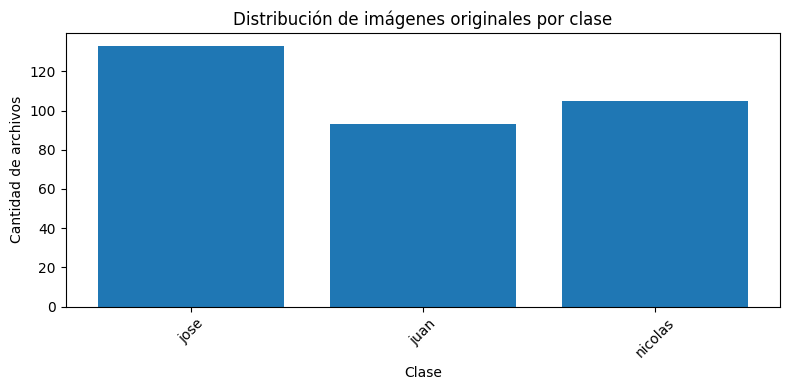

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(class_counts_original["class"], class_counts_original["archivos"])
plt.title("Distribución de imágenes originales por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de archivos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Distribución de formatos
extension_counts = (
    metadata_df
    .groupby("extension")
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

extension_counts.to_csv(REPORTS_DIR / "distribucion_formatos_original.csv", index=False)
extension_counts

,extension,cantidad
2,.jpg,163
3,.png,78
0,.heic,48
1,.jpeg,42


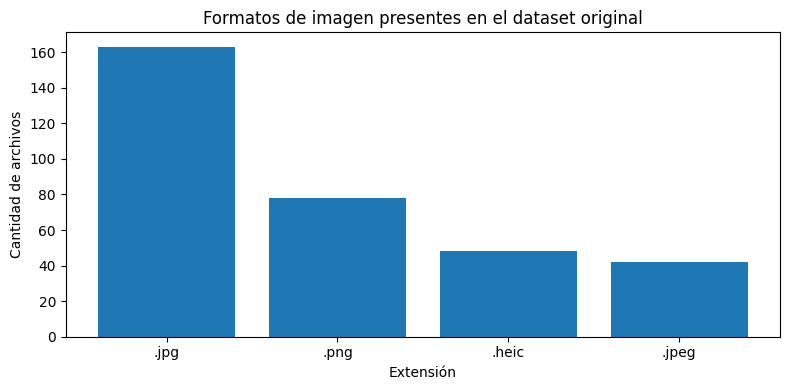

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(extension_counts["extension"], extension_counts["cantidad"])
plt.title("Formatos de imagen presentes en el dataset original")
plt.xlabel("Extensión")
plt.ylabel("Cantidad de archivos")
plt.tight_layout()
plt.show()

In [ ]:
# Estadísticas descriptivas de dimensiones y tamaño de archivo
numeric_summary = metadata_df[["size_mb", "width", "height"]].describe().T
numeric_summary.to_csv(REPORTS_DIR / "estadisticas_descriptivas_original.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
size_mb,331.0,2.546357,2.413640,0.036039,0.71721,2.2421,4.084582,23.423299
width,331.0,2507.836858,1497.844966,235.000000,1148.00000,2304.0000,3984.000000,5712.000000
height,331.0,3218.477341,1769.605485,238.000000,1405.00000,3664.0000,4896.000000,6528.000000


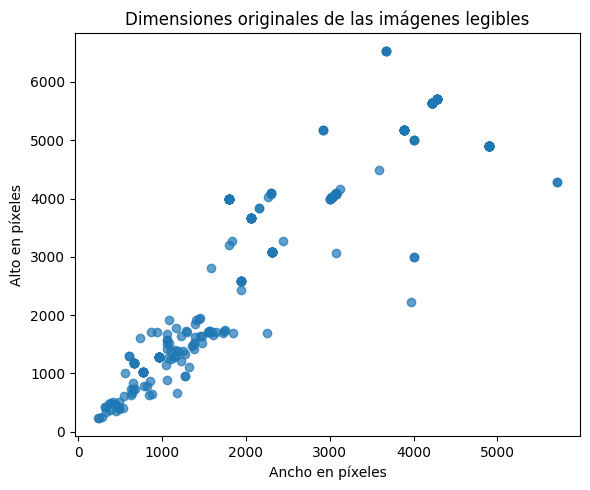

In [ ]:
readable_df = metadata_df[metadata_df["readable"]].copy()

plt.figure(figsize=(6, 5))
plt.scatter(readable_df["width"], readable_df["height"], alpha=0.7)
plt.title("Dimensiones originales de las imágenes legibles")
plt.xlabel("Ancho en píxeles")
plt.ylabel("Alto en píxeles")
plt.tight_layout()
plt.show()

In [ ]:
# Revisión de posibles problemas de calidad antes del preprocesamiento
quality_summary = pd.DataFrame({
    "problema": [
        "Archivos con extensión no soportada",
        "Imágenes no legibles",
        "Imágenes con ancho faltante",
        "Imágenes con alto faltante"
    ],
    "cantidad": [
        int((~metadata_df["is_supported_extension"]).sum()),
        int((~metadata_df["readable"]).sum()),
        int(metadata_df["width"].isna().sum()),
        int(metadata_df["height"].isna().sum())
    ]
})

quality_summary.to_csv(REPORTS_DIR / "resumen_calidad_original.csv", index=False)
quality_summary

,problema,cantidad
0,Archivos con extensión no soportada,0
1,Imágenes no legibles,0
2,Imágenes con ancho faltante,0
3,Imágenes con alto faltante,0


### Interpretación del análisis exploratorio inicial

Con las tablas y visualizaciones anteriores se verifica si el dataset original está balanceado por clase, si todos los archivos tienen formatos compatibles y si las imágenes presentan dimensiones suficientemente consistentes para el procesamiento posterior. Aunque las redes convolucionales pueden recibir imágenes redimensionadas, es necesario estandarizarlas para evitar entradas heterogéneas y facilitar el entrenamiento.

El siguiente paso consiste en limpiar el dataset mediante detección facial, recorte del rostro principal, validación del recorte y transformación a imágenes cuadradas de 224x224 píxeles.

## 5. Preprocesamiento con OpenCV

Esta sección toma el código funcional del notebook base y lo organiza como un pipeline reproducible. El objetivo es convertir las imágenes originales en un dataset limpio de rostros.

El flujo de procesamiento es:

1. Leer imágenes en diferentes formatos.
2. Detectar el rostro principal usando el detector DNN de OpenCV.
3. Recortar el rostro con margen contextual.
4. Validar que el recorte sea utilizable.
5. Redimensionar a 224x224 píxeles.
6. Guardar las imágenes limpias en una nueva carpeta.
7. Copiar las imágenes fallidas en una carpeta de errores para revisión.

In [ ]:
# Descarga del detector facial DNN de OpenCV
!wget -q -O deploy.prototxt https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
!wget -q -O res10_300x300_ssd_iter_140000.caffemodel https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel

print("Archivos del detector facial descargados")

Archivos del detector facial descargados


In [ ]:
# Configuración del detector facial DNN de OpenCV
FACE_NET = cv2.dnn.readNetFromCaffe(
    "deploy.prototxt",
    "res10_300x300_ssd_iter_140000.caffemodel"
)

print("Detector facial cargado correctamente")

Detector facial cargado correctamente


In [ ]:
def read_image_any_format(img_path: Path):
    """Lee una imagen usando PIL como método principal y OpenCV como respaldo."""
    try:
        with Image.open(img_path) as pil_img:
            pil_img = ImageOps.exif_transpose(pil_img)
            pil_img = pil_img.convert("RGB")
            img_rgb = np.array(pil_img)
            img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
            return img_bgr
    except Exception:
        try:
            return cv2.imread(str(img_path))
        except Exception:
            return None

In [ ]:
def detect_main_face(img_bgr, conf_threshold=0.50):
    """Detecta el rostro principal en una imagen BGR usando el detector DNN de OpenCV."""
    h, w = img_bgr.shape[:2]

    blob = cv2.dnn.blobFromImage(
        cv2.resize(img_bgr, (300, 300)),
        1.0,
        (300, 300),
        (104.0, 177.0, 123.0)
    )

    FACE_NET.setInput(blob)
    detections = FACE_NET.forward()

    best_box = None
    best_score = -1

    for i in range(detections.shape[2]):
        confidence = float(detections[0, 0, i, 2])

        if confidence < conf_threshold:
            continue

        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        x1, y1, x2, y2 = box.astype(int)

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        bw = x2 - x1
        bh = y2 - y1

        if bw < 50 or bh < 50:
            continue

        area = bw * bh
        area_ratio = area / (w * h)
        score = (confidence * 0.7) + (area_ratio * 0.3)

        if score > best_score:
            best_score = score
            best_box = (x1, y1, bw, bh, confidence)

    return best_box

In [ ]:
def crop_face_square_safe(img_bgr, face_box, target_face_ratio=0.50):
    """Recorta una región cuadrada centrada en el rostro detectado."""
    x, y, w, h, conf = face_box

    cx = x + w / 2
    cy = y + h / 2
    side = int(max(w, h) / target_face_ratio)

    x1 = int(cx - side / 2)
    y1 = int(cy - side / 2)
    x2 = x1 + side
    y2 = y1 + side

    img_h, img_w = img_bgr.shape[:2]

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    crop = img_bgr[y1:y2, x1:x2]

    if crop is None or crop.size == 0:
        return None

    h_crop, w_crop = crop.shape[:2]
    side_final = min(h_crop, w_crop)

    start_x = (w_crop - side_final) // 2
    start_y = (h_crop - side_final) // 2

    crop_square = crop[start_y:start_y + side_final, start_x:start_x + side_final]
    return crop_square

In [ ]:
def is_valid_face(face_crop):
    """Valida que el recorte del rostro tenga dimensiones mínimas y contenido utilizable."""
    if face_crop is None or face_crop.size == 0:
        return False

    h, w = face_crop.shape[:2]

    if h < 50 or w < 50:
        return False

    return True


def prepare_face_image(img_bgr):
    """Ejecuta detección, recorte, validación y redimensionamiento del rostro."""
    face_box = detect_main_face(img_bgr, conf_threshold=0.50)

    if face_box is None:
        return None

    face_crop = crop_face_square_safe(
        img_bgr,
        face_box,
        target_face_ratio=0.50
    )

    if not is_valid_face(face_crop):
        return None

    face_resized = cv2.resize(
        face_crop,
        (TARGET_SIZE, TARGET_SIZE),
        interpolation=cv2.INTER_AREA
    )

    return face_resized

In [ ]:
def save_error_copy(img_path: Path, person_name: str):
    """Guarda una copia del archivo que no pudo procesarse para revisión posterior."""
    person_error_dir = ERROR_DIR / person_name
    person_error_dir.mkdir(parents=True, exist_ok=True)

    target_path = person_error_dir / img_path.name

    try:
        target_path.write_bytes(img_path.read_bytes())
    except Exception:
        pass

In [ ]:
def process_dataset():
    """Procesa todas las imágenes del dataset y retorna un reporte detallado por archivo."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    ERROR_DIR.mkdir(parents=True, exist_ok=True)

    records = []

    if not INPUT_DIR.exists():
        raise FileNotFoundError(f"No existe la carpeta de entrada: {INPUT_DIR}")

    person_dirs = sorted([p for p in INPUT_DIR.iterdir() if p.is_dir()])

    if not person_dirs:
        raise ValueError("No se encontraron carpetas de personas dentro de la carpeta de entrada.")

    for person_dir in person_dirs:
        person_name = person_dir.name
        output_person_dir = OUTPUT_DIR / person_name
        output_person_dir.mkdir(parents=True, exist_ok=True)

        ok_count = 0
        files = sorted([
            f for f in person_dir.iterdir()
            if f.is_file() and f.suffix.lower() in SUPPORTED_EXTS
        ])

        print(f"\nProcesando clase: {person_name} | archivos encontrados: {len(files)}")

        for img_path in files:
            status = "procesada"
            error_reason = ""
            output_path = ""

            img_bgr = read_image_any_format(img_path)

            if img_bgr is None:
                status = "fallida"
                error_reason = "error_lectura"
                save_error_copy(img_path, person_name)
            else:
                prepared = prepare_face_image(img_bgr)

                if prepared is None:
                    status = "fallida"
                    error_reason = "sin_rostro_o_recorte_invalido"
                    save_error_copy(img_path, person_name)
                else:
                    out_name = f"{person_name}_{ok_count:04d}.jpg"
                    out_path = output_person_dir / out_name
                    cv2.imwrite(str(out_path), prepared)
                    output_path = str(out_path)
                    ok_count += 1

            records.append({
                "class": person_name,
                "input_file": str(img_path),
                "filename": img_path.name,
                "extension": img_path.suffix.lower(),
                "status": status,
                "error_reason": error_reason,
                "output_file": output_path
            })

        print(f" -> procesadas correctamente: {ok_count}")
        print(f" -> fallidas: {len(files) - ok_count}")

    report_df = pd.DataFrame(records)
    report_df.to_csv(REPORTS_DIR / "reporte_preprocesamiento.csv", index=False)

    print("\nProceso finalizado")
    print("Imágenes procesadas:", int((report_df["status"] == "procesada").sum()))
    print("Imágenes fallidas:", int((report_df["status"] == "fallida").sum()))
    print("Dataset limpio en:", OUTPUT_DIR)
    print("Errores en:", ERROR_DIR)

    return report_df

preprocess_report = process_dataset()
preprocess_report.head()


Procesando clase: jose | archivos encontrados: 133
 -> procesadas correctamente: 121
 -> fallidas: 12

Procesando clase: juan | archivos encontrados: 93
 -> procesadas correctamente: 90
 -> fallidas: 3

Procesando clase: nicolas | archivos encontrados: 105
 -> procesadas correctamente: 104
 -> fallidas: 1

Proceso finalizado
Imágenes procesadas: 315
Imágenes fallidas: 16
Dataset limpio en: /content/dataset_limpio
Errores en: /content/imagenes_con_error


,class,input_file,filename,extension,status,error_reason,output_file
0,jose,/content/dataset/dataset_preparado/jose/005A2E...,005A2E03-E81D-4A11-A965-24637613936E_1_105_c.jpeg,.jpeg,fallida,sin_rostro_o_recorte_invalido,
1,jose,/content/dataset/dataset_preparado/jose/1.png,1.png,.png,procesada,,/content/dataset_limpio/jose/jose_0000.jpg
2,jose,/content/dataset/dataset_preparado/jose/112D7D...,112D7D16-44CB-426F-9ADE-EEEB6B106A5B_1_105_c.jpeg,.jpeg,fallida,sin_rostro_o_recorte_invalido,
3,jose,/content/dataset/dataset_preparado/jose/118077...,11807757-91C7-4401-A2D0-B5419606F595_1_105_c.jpeg,.jpeg,procesada,,/content/dataset_limpio/jose/jose_0001.jpg
4,jose,/content/dataset/dataset_preparado/jose/18B8B7...,18B8B764-457E-482C-8B47-E13151884C05_1_105_c.jpeg,.jpeg,procesada,,/content/dataset_limpio/jose/jose_0002.jpg


## 6. Verificación del dataset limpio

Después del preprocesamiento se revisa cuántas imágenes fueron procesadas correctamente, cuántas fueron descartadas y cómo quedó la distribución por clase. Esta sección es clave para demostrar limpieza, manejo de errores y trazabilidad.

In [ ]:
preprocess_summary = (
    preprocess_report
    .groupby(["class", "status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

if "procesada" not in preprocess_summary.columns:
    preprocess_summary["procesada"] = 0
if "fallida" not in preprocess_summary.columns:
    preprocess_summary["fallida"] = 0

preprocess_summary["total"] = preprocess_summary["procesada"] + preprocess_summary["fallida"]
preprocess_summary["tasa_exito"] = np.where(
    preprocess_summary["total"] > 0,
    preprocess_summary["procesada"] / preprocess_summary["total"],
    0
)

preprocess_summary.to_csv(REPORTS_DIR / "resumen_preprocesamiento_por_clase.csv", index=False)
preprocess_summary

status,class,fallida,procesada,total,tasa_exito
0,jose,12,121,133,0.909774
1,juan,3,90,93,0.967742
2,nicolas,1,104,105,0.990476


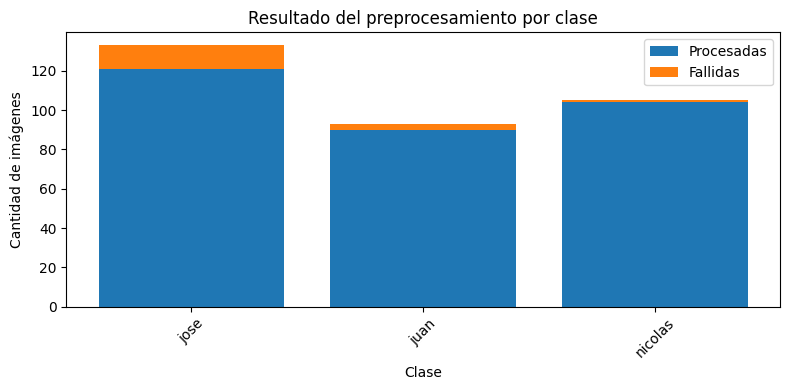

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(preprocess_summary["class"], preprocess_summary["procesada"], label="Procesadas")
plt.bar(preprocess_summary["class"], preprocess_summary["fallida"], bottom=preprocess_summary["procesada"], label="Fallidas")
plt.title("Resultado del preprocesamiento por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def get_clean_metadata(clean_dir: Path):
    records = []
    for class_dir in sorted([p for p in clean_dir.iterdir() if p.is_dir()]):
        for file_path in sorted(class_dir.glob("*.jpg")):
            img = cv2.imread(str(file_path))
            if img is None:
                continue
            h, w = img.shape[:2]
            records.append({
                "filepath": str(file_path),
                "filename": file_path.name,
                "class": class_dir.name,
                "width": w,
                "height": h,
                "size_mb": file_path.stat().st_size / (1024 ** 2)
            })
    return pd.DataFrame(records)

clean_metadata_df = get_clean_metadata(OUTPUT_DIR)
clean_metadata_df.to_csv(REPORTS_DIR / "metadata_dataset_limpio.csv", index=False)
clean_metadata_df.head()

,filepath,filename,class,width,height,size_mb
0,/content/dataset_limpio/jose/jose_0000.jpg,jose_0000.jpg,jose,224,224,0.018031
1,/content/dataset_limpio/jose/jose_0001.jpg,jose_0001.jpg,jose,224,224,0.018476
2,/content/dataset_limpio/jose/jose_0002.jpg,jose_0002.jpg,jose,224,224,0.017832
3,/content/dataset_limpio/jose/jose_0003.jpg,jose_0003.jpg,jose,224,224,0.014360
4,/content/dataset_limpio/jose/jose_0004.jpg,jose_0004.jpg,jose,224,224,0.020207


In [ ]:
clean_summary = pd.DataFrame({
    "métrica": [
        "Total de imágenes limpias",
        "Total de clases limpias",
        "Ancho mínimo",
        "Ancho máximo",
        "Alto mínimo",
        "Alto máximo"
    ],
    "valor": [
        len(clean_metadata_df),
        clean_metadata_df["class"].nunique(),
        clean_metadata_df["width"].min(),
        clean_metadata_df["width"].max(),
        clean_metadata_df["height"].min(),
        clean_metadata_df["height"].max()
    ]
})

clean_summary.to_csv(REPORTS_DIR / "resumen_dataset_limpio.csv", index=False)
clean_summary

,métrica,valor
0,Total de imágenes limpias,315
1,Total de clases limpias,3
2,Ancho mínimo,224
3,Ancho máximo,224
4,Alto mínimo,224
5,Alto máximo,224


In [ ]:
clean_class_counts = (
    clean_metadata_df
    .groupby("class")
    .size()
    .reset_index(name="imagenes_limpias")
    .sort_values("imagenes_limpias", ascending=False)
)

clean_class_counts.to_csv(REPORTS_DIR / "distribucion_clases_dataset_limpio.csv", index=False)
clean_class_counts

,class,imagenes_limpias
0,jose,121
2,nicolas,104
1,juan,90


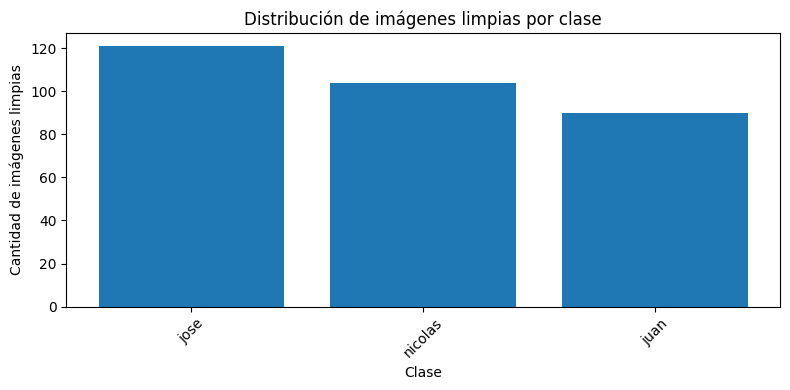

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(clean_class_counts["class"], clean_class_counts["imagenes_limpias"])
plt.title("Distribución de imágenes limpias por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes limpias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8315/4071319912.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = clean_metadata_df.groupby("class", group_keys=False).apply(


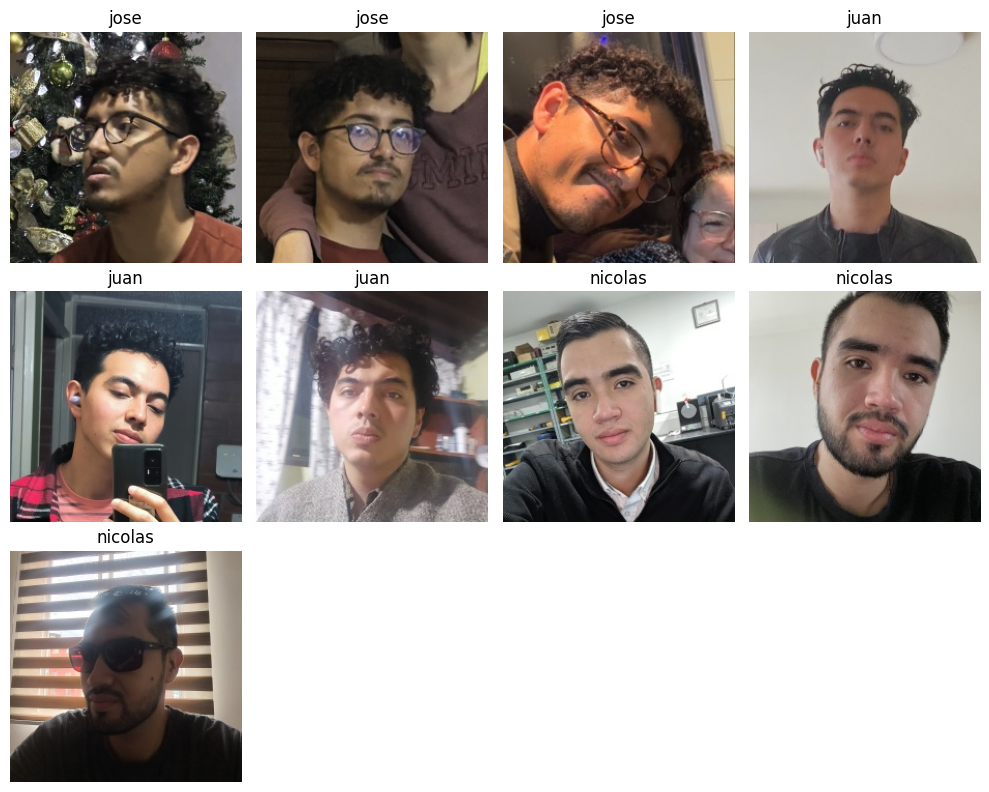

In [ ]:
# Visualización de ejemplos del dataset limpio
sample_df = clean_metadata_df.groupby("class", group_keys=False).apply(
    lambda x: x.sample(min(3, len(x)), random_state=SEED)
).reset_index(drop=True)

plt.figure(figsize=(10, 8))

for i, row in sample_df.head(12).iterrows():
    img_bgr = cv2.imread(row["filepath"])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_rgb)
    plt.title(row["class"])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Interpretación del dataset limpio

El dataset limpio corresponde a la versión utilizable para entrenamiento. En esta versión, todas las imágenes conservadas tienen rostro detectable, fueron recortadas alrededor de la región facial y quedaron estandarizadas a 224x224 píxeles. Las imágenes no procesables no se eliminan sin trazabilidad, sino que quedan copiadas en la carpeta de errores para revisión.

Este proceso cumple con la limpieza y transformación requerida, ya que convierte un conjunto heterogéneo de imágenes originales en una estructura homogénea y preparada para modelamiento.

## 7. Separación del dataset en entrenamiento, validación y prueba

Se divide el dataset limpio en tres subconjuntos:

- **Entrenamiento:** 70% de las imágenes.
- **Validación:** 15% de las imágenes.
- **Prueba:** 15% de las imágenes.

La separación se realiza de forma estratificada para conservar la proporción de clases en cada subconjunto.

In [ ]:
filepaths = clean_metadata_df["filepath"].tolist()
labels = clean_metadata_df["class"].tolist()

if len(set(labels)) < 2:
    raise ValueError("Se requieren al menos dos clases para entrenar un modelo de clasificación.")

# División estratificada: train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

# División del 30% temporal en validación 15% y prueba 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

train_df = pd.DataFrame({"filename": X_train, "class": y_train, "split": "train"})
val_df = pd.DataFrame({"filename": X_val, "class": y_val, "split": "validation"})
test_df = pd.DataFrame({"filename": X_test, "class": y_test, "split": "test"})

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

train_df.to_csv(REPORTS_DIR / "train_df.csv", index=False)
val_df.to_csv(REPORTS_DIR / "val_df.csv", index=False)
test_df.to_csv(REPORTS_DIR / "test_df.csv", index=False)
split_df.to_csv(REPORTS_DIR / "split_dataset.csv", index=False)

split_df.head()

,filename,class,split
0,/content/dataset_limpio/nicolas/nicolas_0028.jpg,nicolas,train
1,/content/dataset_limpio/jose/jose_0077.jpg,jose,train
2,/content/dataset_limpio/jose/jose_0028.jpg,jose,train
3,/content/dataset_limpio/juan/juan_0016.jpg,juan,train
4,/content/dataset_limpio/juan/juan_0007.jpg,juan,train


In [ ]:
split_summary = (
    split_df
    .groupby(["split", "class"])
    .size()
    .reset_index(name="cantidad")
)

split_summary_pivot = split_summary.pivot(index="class", columns="split", values="cantidad").fillna(0).astype(int)
split_summary_pivot["total"] = split_summary_pivot.sum(axis=1)
split_summary_pivot.to_csv(REPORTS_DIR / "resumen_particiones_por_clase.csv")
split_summary_pivot

split,test,train,validation,total
class,,,,
jose,19,84,18,121
juan,13,63,14,90
nicolas,16,73,15,104


In [ ]:
split_totals = (
    split_df
    .groupby("split")
    .size()
    .reset_index(name="cantidad")
)
split_totals["porcentaje"] = split_totals["cantidad"] / split_totals["cantidad"].sum()
split_totals.to_csv(REPORTS_DIR / "resumen_particiones.csv", index=False)
split_totals

,split,cantidad,porcentaje
0,test,48,0.152381
1,train,220,0.698413
2,validation,47,0.149206


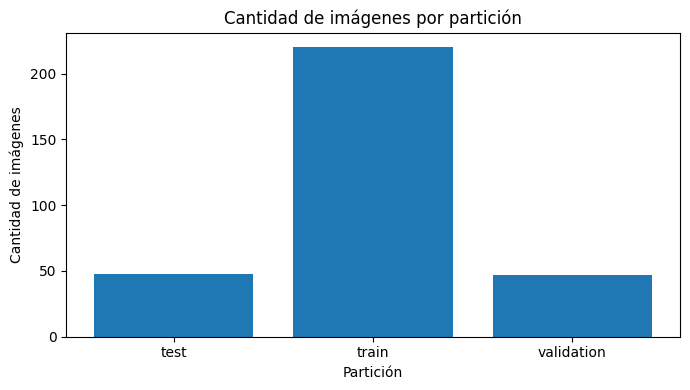

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(split_totals["split"], split_totals["cantidad"])
plt.title("Cantidad de imágenes por partición")
plt.xlabel("Partición")
plt.ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()

In [ ]:
# Creación física de carpetas train, validation y test para trazabilidad y entrega
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for _, row in split_df.iterrows():
    src = Path(row["filename"])
    split = row["split"]
    cls = row["class"]
    dst_dir = SPLIT_DIR / split / cls
    dst_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst_dir / src.name)

print("Dataset particionado creado en:", SPLIT_DIR)
print(os.listdir(SPLIT_DIR))

Dataset particionado creado en: /content/dataset_split
['train', 'test', 'validation']


In [ ]:
# Compresión de entregables de datos procesados y particiones
clean_zip = BASE_DIR / "dataset_limpio.zip"
split_zip = BASE_DIR / "particiones_dataset.zip"
reports_zip = BASE_DIR / "reportes_fase2.zip"

shutil.make_archive(str(clean_zip).replace(".zip", ""), "zip", OUTPUT_DIR)
shutil.make_archive(str(split_zip).replace(".zip", ""), "zip", SPLIT_DIR)
shutil.make_archive(str(reports_zip).replace(".zip", ""), "zip", REPORTS_DIR)

print("Archivos ZIP generados:")
print(clean_zip)
print(split_zip)
print(reports_zip)

Archivos ZIP generados:
/content/dataset_limpio.zip
/content/particiones_dataset.zip
/content/reportes_fase2.zip


## 8. Generadores de imágenes para entrenamiento

Se crean generadores con Keras a partir de los dataframes de partición. Para el modelo base se utiliza solo el preprocesamiento requerido por VGG16. Para el segundo modelo se adicionan transformaciones de data augmentation sobre el conjunto de entrenamiento.

In [ ]:
NUM_CLASSES = split_df["class"].nunique()
CLASS_NAMES = sorted(split_df["class"].unique())

print("Número de clases:", NUM_CLASSES)
print("Clases:", CLASS_NAMES)

Número de clases: 3
Clases: ['jose', 'juan', 'nicolas']


In [ ]:
# Generadores para el modelo 1: transfer learning sin data augmentation
base_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_base = base_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = base_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

test_generator = base_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

Found 220 validated image filenames belonging to 3 classes.
Found 47 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.


In [ ]:
# Generador para el modelo 2: transfer learning con data augmentation
augmentation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator_aug = augmentation_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

Found 220 validated image filenames belonging to 3 classes.


Found 220 validated image filenames belonging to 3 classes.


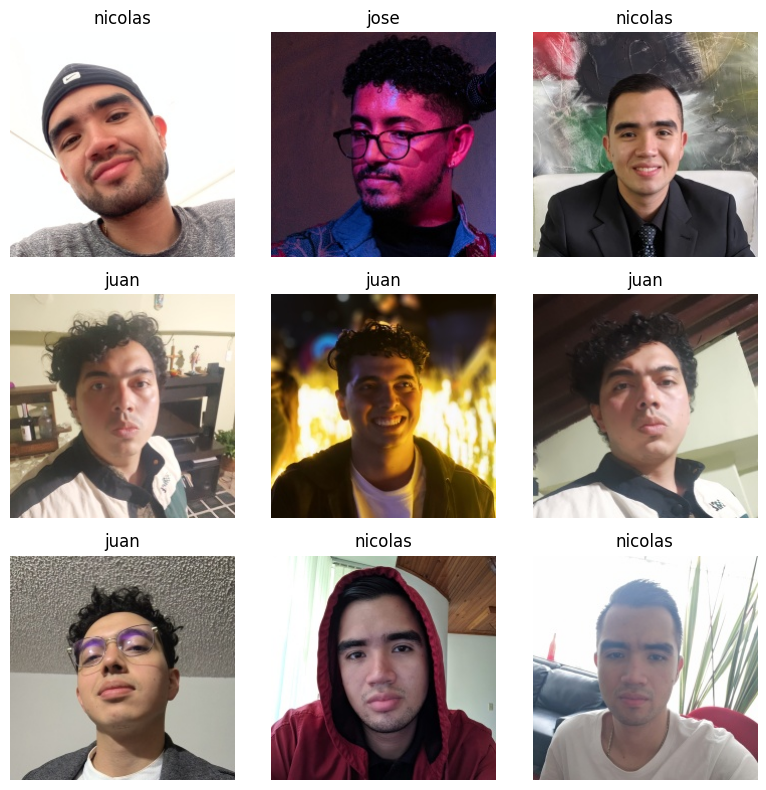

In [ ]:
# Visualización de un batch del generador base sin aplicar preprocess_input para mostrar imágenes legibles
preview_datagen = ImageDataGenerator()
preview_generator = preview_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=9,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

images, labels_batch = next(preview_generator)
class_indices = preview_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

plt.figure(figsize=(8, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype("uint8"))
    plt.title(idx_to_class[np.argmax(labels_batch[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()